# 09 Classification - Limitations of Linear Regression

This notebook demonstrates why linear regression is not suitable for classification problems.

이 노트북에서는 classification 문제에서  
linear Regression이 왜 적절하지 않은지 확인한다.

we will apply linear regression to a binary classification problem  
and observe its limitations.

binany classification 문제에 linear regression을 적용하고  
그 한계를 직접 확인한다.

## 1. Binary Classification Problem

In classification, the output y can take only a few discrete values.

classification에서는 출력 y가 몇 가지 값만 가질 수 있다.

For binary classification:  
- y = 0 (negative class)
- y = 1 (positive class)

binary classification에서는
y가 0 또는 1 값을 가진다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 2. Create a Simple Classification Dataset

We create a dataset where:
- small x -> y = 0
- large x -> y = 1

작은 x는 0, 큰 x는 1이 되도록 데이터 생성

In [2]:
# 간단한 binary dataset
x_train = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=float)
y_train = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=float)

X = x_train.reshape(-1 , 1)

print("X:", X.T)
print("y:", y_train)

X: [[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]]
y: [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]


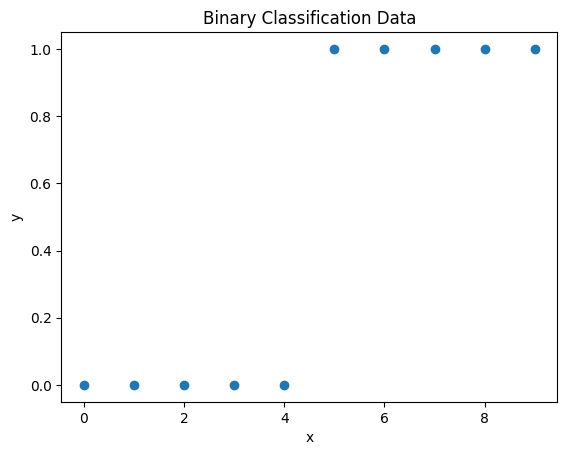

In [3]:
plt.scatter(x_train, y_train)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Binary Classification Data")
plt.show()

## 3. Apply Linear Regression

We try to fit a straight line to this classification data.

classification 데이터에 linear regression을 적용한다.

In [4]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    preds = X @ w + b
    return (1/(2*m)) * np.sum((preds - y)**2)

def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        error = (X[i] @ w + b) - y[i]
        dj_dw += error * X[i]
        dj_db += error

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

def gradient_descent(X, y, w, b, alpha, iterations):
    for _ in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
    return w, b

In [5]:
w = np.zeros(1)
b = 0.0

w, b = gradient_descent(X, y_train, w, b, alpha=0.01, iterations=1000)

print("w:", w)
print("b:", b)

w: [0.15]
b: -0.1699360132666258


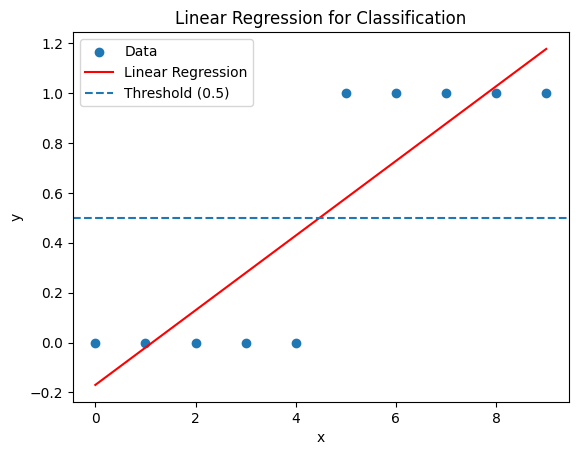

In [ ]:
# 예측 직선
x_line = np.linspace(0, 9, 100)
y_line = x_line * w + b

plt.scatter(x_train, y_train, label = "Data")
plt.plot(x_line, y_line, color='red', label="Linear Regression")
# 0.5 위치에 가로선 그리기
plt.axhline(0.5, linestyle='--', label="Threshold (0.5)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression for Classification")
plt.legend()
plt.show()

## Using a Threshold

We can convert predictions into classes using a threshold

threshold(임계값)를 사용해 classification을 수행

Example:
- y < 0.5 -> 0
- y >= 0.5 -> 1

## 5. Problem: Sensitivity to Outliers

Linear Regression is sensitive to outliers.

linear regression은 이상치(outliers)에 매우 민감하다.

Let's add one extreme data point.

In [11]:
# outlier 추가
# 기존 배열 맨 뒤에 20 추가 즉, 이상치 추가
# 선형 회귀가 왜 위험한지 실험
x_train_out = np.append(x_train, 20)
y_train_out = np.append(y_train, 1)

X_out = x_train_out.reshape(-1,1)

In [9]:
w2 = np.zeros(1)
b2 = 0.0

w2, b2 = gradient_descent(X_out, y_train_out, w2, b2, alpha=0.01, iterations=1000)

print("w:", w2)
print("b:", b2)

w: [0.065]
b: 0.15966894314675756


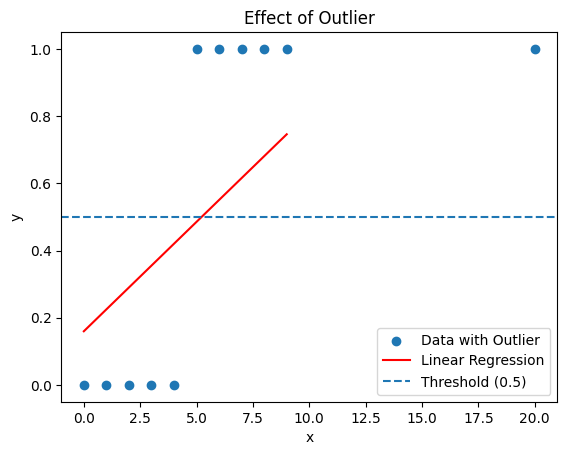

In [10]:
y_line2 = w2 * x_line + b2

plt.scatter(x_train_out, y_train_out, label="Data with Outlier")
plt.plot(x_line, y_line2, color='red', label="Linear Regression")
plt.axhline(0.5, linestyle='--', label="Threshold (0.5)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of Outlier")
plt.legend()
plt.show()

## Conclusion

Linear regression is not suitable for classification problems.

linear regression은 classification 문제에 적합하지 않다.

Problems:
1. Output is not limited to 0 and 1  
   출력이 0~1로 제한되지 않는다  

2. Sensitive to outliers  
   이상치에 매우 민감하다  


3. Decision boundary can change drastically  
   decision boundary가 크게 변할 수 있다  

Therefore, we need a better algorithm → Logistic Regression

따라서 classification을 위해 logistic regression이 필요하다.